# Phase 3 — Feature Extraction
**RealCentric Generator-Agnostic Deepfake Detection**  
SVKM AI/ML HPC Cluster

Extracts and saves 718-dim fused feature vectors for all images.

| Group | Dims | Description |
|---|---|---|
| Statistical | 4 | Mean, variance, entropy, Mahalanobis |
| Frequency | 2 | Spectral slope, energy ratio |
| Wavelet | 200 | Sub-band energies + moments |
| CNN (ResNet-18) | 512 | Learned hierarchical features |

**Estimated time on H100:** 45–90 minutes total  
Project root: `/data/mpstme-naman/deepfake_detection`

## Step 1 — Verify GPU and Data

In [1]:
import sys
sys.path.insert(0, '/data/mpstme-naman/deepfake_detection')
import torch, numpy as np
from pathlib import Path

BASE = Path('/data/mpstme-naman/deepfake_detection')
PROC = BASE / 'data' / 'processed'

print('=' * 58)
print(f'  PyTorch  : {torch.__version__}')
print(f'  GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (no GPU!)"}'  )
if torch.cuda.is_available():
    print(f'  VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('=' * 58)
print('\nProcessed data check:')
for name, sub in [('CelebDF','celebdf'),('FaceForensics','ff'),('Stable Diffusion','sd')]:
    rd = PROC/sub/'real'; fd = PROC/sub/'fake'
    rn = len(list(rd.glob('*.png'))) if rd.exists() else 0
    fn = len(list(fd.glob('*.png'))) if fd.exists() else 0
    ok = '✓' if rn+fn > 0 else '✗  RUN PREPROCESSING FIRST'
    print(f'  {ok}  {name:<18} real={rn:,}  fake={fn:,}')

  PyTorch  : 2.9.0a0+145a3a7bda.nv25.10
  GPU      : NVIDIA H100 PCIe MIG 3g.40gb
  VRAM     : 42.4 GB

Processed data check:
  ✓  CelebDF            real=29,097  fake=25,036
  ✓  FaceForensics      real=27,308  fake=131,743
  ✓  Stable Diffusion   real=0  fake=9,000


## Step 2 — Set Up Paths

In [2]:
from config.config_loader import load_config
import time

cfg = load_config()

BASE     = Path('/data/mpstme-naman/deepfake_detection')
PROC     = BASE / 'data' / 'processed'
FEAT_DIR = BASE / 'data' / 'features'
CKPT_DIR = BASE / 'checkpoints'
RES_DIR  = BASE / 'results'

for d in [FEAT_DIR, CKPT_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Set to 5000 for a quick 10-min test run; None = use ALL images
MAX_PER_CLASS = None

print(f'  Features    → {FEAT_DIR}')
print(f'  Checkpoints → {CKPT_DIR}')
print(f'  Max/class   : {MAX_PER_CLASS if MAX_PER_CLASS else "ALL"}')

  Features    → /data/mpstme-naman/deepfake_detection/data/features
  Checkpoints → /data/mpstme-naman/deepfake_detection/checkpoints
  Max/class   : ALL


## Step 3 — Load Images from Disk

In [3]:
import cv2
from tqdm import tqdm

def load_folder(folder, label, max_n=None):
    folder = Path(folder)
    if not folder.exists():
        print(f'  WARNING: {folder} not found'); return [], []
    paths = sorted(folder.glob('*.png'))
    if max_n: paths = paths[:max_n]
    imgs, lbls = [], []
    for p in tqdm(paths, desc=f'  {folder.parent.name}/{folder.name}', leave=False):
        img = cv2.imread(str(p))
        if img is not None: imgs.append(img); lbls.append(label)
    return imgs, lbls

print('Loading images from disk...\n')
celebdf_real, clr = load_folder(PROC/'celebdf'/'real', 0, MAX_PER_CLASS)
celebdf_fake, clf = load_folder(PROC/'celebdf'/'fake', 1, MAX_PER_CLASS)
ff_real,      ffr = load_folder(PROC/'ff'/'real',      0, MAX_PER_CLASS)
ff_fake,      fff = load_folder(PROC/'ff'/'fake',      1, MAX_PER_CLASS)
sd_fake,      sdf = load_folder(PROC/'sd'/'fake',      1, MAX_PER_CLASS)

print(f'\n  CelebDF       real={len(celebdf_real):,}   fake={len(celebdf_fake):,}')
print(f'  FaceForensics real={len(ff_real):,}   fake={len(ff_fake):,}')
print(f'  Stable Diff   fake={len(sd_fake):,}')
print(f'\n  Total: {len(celebdf_real)+len(celebdf_fake)+len(ff_real)+len(ff_fake)+len(sd_fake):,} images')

Loading images from disk...




  CelebDF       real=29,097   fake=25,036
  FaceForensics real=27,308   fake=131,743
  Stable Diff   fake=9,000

  Total: 222,184 images


## Step 4 — Initialise Feature Pipeline

In [4]:
from src.features.extractor import FeatureFusionPipeline
pipeline = FeatureFusionPipeline(cfg=cfg, backbone=cfg['features']['cnn']['backbones'][0])
print(pipeline.describe())
print(f'\n  Output dimension: {pipeline.output_dim}')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  CNN Backbone: GPU — NVIDIA H100 PCIe MIG 3g.40gb  (42.4 GB)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 50463.51it/s]
CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEX

Feature Fusion Pipeline
  Backbone      : clip_vit_b32
  Envelope fit  : False
  Norm fit      : False

  Component dimensions:
    Statistical   :      4-dim  [μ, σ², H, Mahalanobis]
    Frequency     :      2-dim  [spectral slope s, energy ratio R]
    Wavelet       :    200-dim  [energies + moments + ratios + histograms]
    CNN           :    512-dim  [clip_vit_b32 penultimate layer]
    --------------------------------------
    Fused z       :    718-dim

  Output dimension: 718


## Step 5 — Fit Real-Image Envelope

This calibrates the Mahalanobis distance using real images only.

In [5]:
fit_imgs = celebdf_real[:10000]
print(f'Fitting envelope on {len(fit_imgs):,} real images...')
t0 = time.time()
pipeline.fit_on_real(fit_imgs)
print(f'Done in {time.time()-t0:.1f}s  ✓')

Fitting envelope on 10,000 real images...
  Fitting pipeline on 10000 real images...
    [1/3] Statistical envelope... done
    [2/3] Feature normalisation... done
    [3/3] Pipeline ready
  Fused vector dim: 718
Done in 349.2s  ✓


## Step 6 — Save Pipeline State (Important!)

In [6]:
import pickle
path = CKPT_DIR / 'pipeline_state.pkl'
with open(path, 'wb') as f:
    pickle.dump(pipeline.get_state(), f)
print(f'  ✓  {path}  ({path.stat().st_size/1e6:.1f} MB)')
print('  All future notebooks load this file — never refit again.')

  ✓  /data/mpstme-naman/deepfake_detection/checkpoints/pipeline_state.pkl  (0.0 MB)
  All future notebooks load this file — never refit again.


## Step 7 — Extract CelebDF Features
**~15–30 minutes**

In [7]:
imgs = celebdf_real + celebdf_fake
lbls = np.array(clr + clf)
print(f'Extracting CelebDF ({len(imgs):,} images)...')
t0 = time.time()
Z = pipeline.extract_batch(imgs, normalise=True, cnn_batch_size=64)
print(f'  {time.time()-t0:.0f}s  shape={Z.shape}  NaN={np.isnan(Z).sum()}')
np.save(FEAT_DIR/'Z_celebdf.npy', Z); np.save(FEAT_DIR/'y_celebdf.npy', lbls)
print('  ✓  Z_celebdf.npy saved')
del celebdf_real, celebdf_fake, imgs

Extracting CelebDF (54,133 images)...
  2066s  shape=(54133, 974)  NaN=0
  ✓  Z_celebdf.npy saved


## Step 8 — Extract FaceForensics++ Features
**~30–60 minutes**

In [8]:
imgs = ff_real + ff_fake
lbls = np.array(ffr + fff)
print(f'Extracting FaceForensics++ ({len(imgs):,} images)...')
t0 = time.time()
Z = pipeline.extract_batch(imgs, normalise=True, cnn_batch_size=64)
print(f'  {time.time()-t0:.0f}s  shape={Z.shape}  NaN={np.isnan(Z).sum()}')
np.save(FEAT_DIR/'Z_ff.npy', Z); np.save(FEAT_DIR/'y_ff.npy', lbls)
print('  ✓  Z_ff.npy saved')
del ff_real, ff_fake, imgs

Extracting FaceForensics++ (159,051 images)...
  5885s  shape=(159051, 974)  NaN=0
  ✓  Z_ff.npy saved


## Step 9 — Extract Stable Diffusion Features
**~3–5 minutes**

In [9]:
lbls = np.array(sdf)
print(f'Extracting Stable Diffusion ({len(sd_fake):,} images)...')
t0 = time.time()
Z = pipeline.extract_batch(sd_fake, normalise=True, cnn_batch_size=64)
print(f'  {time.time()-t0:.0f}s  shape={Z.shape}')
np.save(FEAT_DIR/'Z_sd.npy', Z); np.save(FEAT_DIR/'y_sd.npy', lbls)
print('  ✓  Z_sd.npy saved')
del sd_fake

Extracting Stable Diffusion (9,000 images)...
  343s  shape=(9000, 974)
  ✓  Z_sd.npy saved


## Step 10 — Create Train / Val / Test Splits

In [10]:
from sklearn.model_selection import train_test_split

Z_all = np.load(FEAT_DIR/'Z_celebdf.npy')
y_all = np.load(FEAT_DIR/'y_celebdf.npy')

Z_tr, Z_tmp, y_tr, y_tmp = train_test_split(Z_all, y_all, test_size=0.30, random_state=42, stratify=y_all)
Z_val, Z_test, y_val, y_test = train_test_split(Z_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

for name, Z, y in [('train',Z_tr,y_tr),('val',Z_val,y_val),('test',Z_test,y_test)]:
    np.save(FEAT_DIR/f'Z_{name}.npy', Z); np.save(FEAT_DIR/f'y_{name}.npy', y)

print(f'  Train : {len(y_tr):,}   real={(y_tr==0).sum():,}  fake={(y_tr==1).sum():,}')
print(f'  Val   : {len(y_val):,}   real={(y_val==0).sum():,}  fake={(y_val==1).sum():,}')
print(f'  Test  : {len(y_test):,}   real={(y_test==0).sum():,}  fake={(y_test==1).sum():,}')
print('  ✓  All splits saved')

  Train : 37,893   real=20,368  fake=17,525
  Val   : 8,120   real=4,364  fake=3,756
  Test  : 8,120   real=4,365  fake=3,755
  ✓  All splits saved


## Step 11 — Sanity Check: Feature Distribution Plot

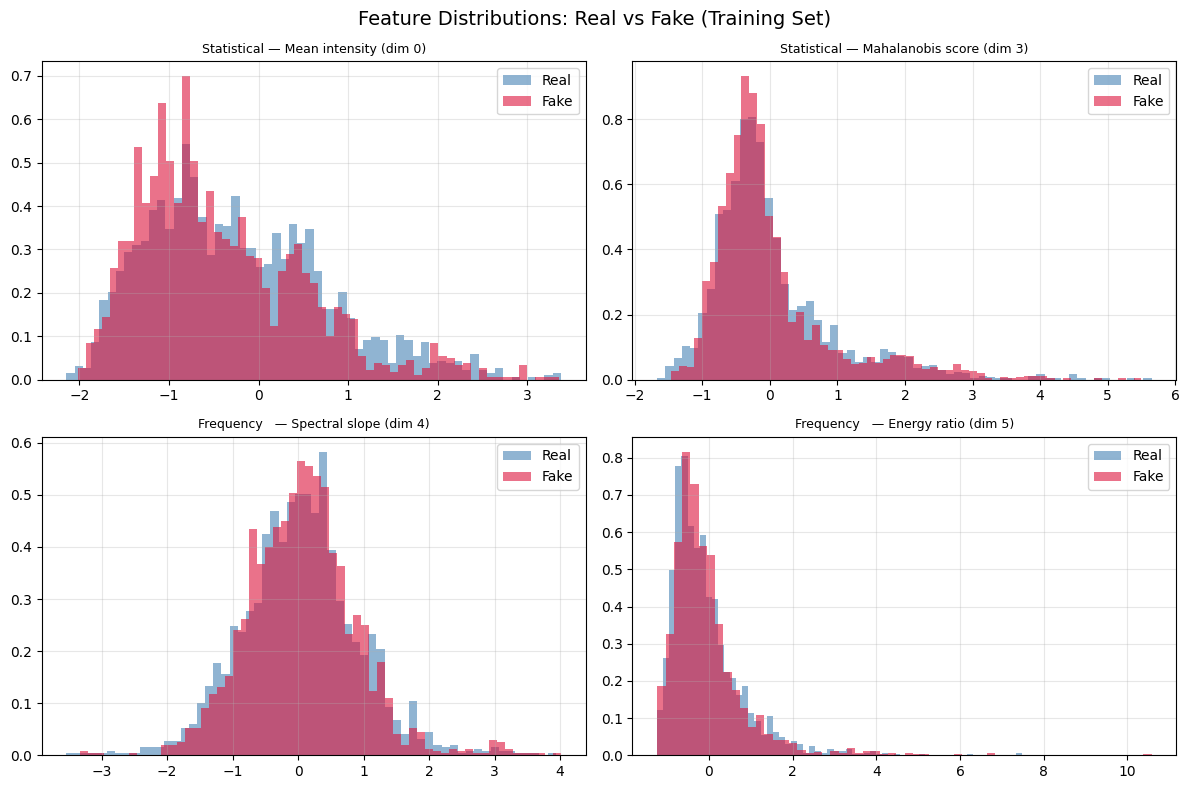

  ✓  /data/mpstme-naman/deepfake_detection/results/feature_distributions.png


In [11]:
import matplotlib.pyplot as plt
Z_tr = np.load(FEAT_DIR/'Z_train.npy'); y_tr = np.load(FEAT_DIR/'y_train.npy')
rZ = Z_tr[y_tr==0]; fZ = Z_tr[y_tr==1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions: Real vs Fake (Training Set)', fontsize=14)
for ax,(title,idx) in zip(axes.flat,[
    ('Statistical — Mean intensity (dim 0)', 0),
    ('Statistical — Mahalanobis score (dim 3)', 3),
    ('Frequency   — Spectral slope (dim 4)', 4),
    ('Frequency   — Energy ratio (dim 5)', 5)]):
    ax.hist(rZ[:2000,idx], bins=60, alpha=0.6, color='steelblue', label='Real', density=True)
    ax.hist(fZ[:2000,idx], bins=60, alpha=0.6, color='crimson',   label='Fake', density=True)
    ax.set_title(title, fontsize=9); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
out = RES_DIR/'feature_distributions.png'
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'  ✓  {out}')

## Step 12 — File Summary

In [12]:
print('Feature files saved:')
print('='*62)
for f in sorted(FEAT_DIR.glob('*.npy')):
    arr = np.load(f, mmap_mode='r')
    print(f'  {f.name:<28} shape={str(arr.shape):<20} {f.stat().st_size/1e6:>6.1f} MB')
print()
print('Checkpoints:')
for f in sorted(CKPT_DIR.glob('*.pkl')):
    print(f'  {f.name:<32} {f.stat().st_size/1e6:>6.1f} MB')
print()
print('  ✅  Phase 3 — Feature Extraction COMPLETE')
print('  Next: Open 03_train_supervised.ipynb')

Feature files saved:
  Z_celebdf.npy                shape=(54133, 974)          210.9 MB
  Z_ff.npy                     shape=(159051, 974)         619.7 MB
  Z_sd.npy                     shape=(9000, 974)            35.1 MB
  Z_test.npy                   shape=(8120, 974)            31.6 MB
  Z_train.npy                  shape=(37893, 974)          147.6 MB
  Z_val.npy                    shape=(8120, 974)            31.6 MB
  y_celebdf.npy                shape=(54133,)                0.4 MB
  y_ff.npy                     shape=(159051,)               1.3 MB
  y_sd.npy                     shape=(9000,)                 0.1 MB
  y_test.npy                   shape=(8120,)                 0.1 MB
  y_train.npy                  shape=(37893,)                0.3 MB
  y_val.npy                    shape=(8120,)                 0.1 MB

Checkpoints:
  ensemble.pkl                        4.9 MB
  pipeline_state.pkl                  0.0 MB

  ✅  Phase 3 — Feature Extraction COMPLETE
  Next: Open 03